In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.feature_selection import RFE
from sklearn.datasets import load_diabetes

In [15]:
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
# Task 1 (Exploration) 

In [13]:
diabetes = load_diabetes()
X = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
y = pd.Series(diabetes.target, name="target")

#features = ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) 

In [48]:
feature_ranges = (X.max(),X.min()) 
print(feature_ranges)
print(y.max(), y.min())

(age    0.110727
sex    0.050680
bmi    0.170555
bp     0.132044
s1     0.153914
s2     0.198788
s3     0.181179
s4     0.185234
s5     0.133597
s6     0.135612
dtype: float64, age   -0.107226
sex   -0.044642
bmi   -0.090275
bp    -0.112399
s1    -0.126781
s2    -0.115613
s3    -0.102307
s4    -0.076395
s5    -0.126097
s6    -0.137767
dtype: float64)
346.0 25.0


In [43]:
# Task 2 (Linear Model w split)

In [16]:
full_model = LinearRegression()
full_model.fit(X_train, y_train)
full_pred = full_model.predict(X_test)

# Metrics for Full Model
full_mse = mean_squared_error(y_test, full_pred)
full_r2 = r2_score(y_test, full_pred)
print("Full Model Metrics:")
print(f"MSE: {full_mse:.2f}, R²: {full_r2:.2f}")


Full Model Metrics:
MSE: 2900.19, R²: 0.45


In [17]:
# Task 3

In [34]:
# Recursive Feature Elimination (RFE) with Cross-Validation
cv_scores = []
num_features = []
coefficients_list = []           

coef_table = pd.DataFrame(               # Coefficents in table
    index=range(1, X_train.shape[1] + 1),
    columns=X_train.columns
)

for k in range(1, X_train.shape[1] + 1): # Feature elimination
    rfe = RFE(estimator=LinearRegression(), n_features_to_select=k)
    rfe.fit(X_train, y_train)
    
    # Cross-validation to assess performance
    scores = cross_val_score(rfe, X_train, y_train, scoring='r2', cv=5)
    cv_scores.append(scores.mean())
    num_features.append(k)
    
    selected_features = X_train.columns[rfe.support_]    # Saving Coefficents 
    coefficients = rfe.estimator_.coef_
    coefficients_list.append(dict(zip(selected_features, coefficients)))

    # Fit reduced model
    X_reduced = X_train.loc[:, rfe.support_]
    model = LinearRegression()
    model.fit(X_reduced, y_train)

    coef_table.loc[k] = 0

    # Coefficients for selected features
    coef_table.loc[k, selected_features] = model.coef_

# Optimal number of features using threshold
improvements = np.diff(cv_scores)

threshold = 0.01
optimal_features = 0

for i, imp in enumerate(improvements):
    if imp < threshold: 
        optimal_features = num_features[i]
        break

print(f"Optimal number of features: {optimal_features}")

Optimal number of features: 2


In [35]:
# Train Final Model with Optimal Features
rfe = RFE(estimator=LinearRegression(), n_features_to_select=optimal_features)
rfe.fit(X_train, y_train)

# Reduced Model
X_train_reduced = X_train.loc[:, rfe.support_]
X_test_reduced  = X_test.loc[:, rfe.support_]

reduced_model = LinearRegression()
reduced_model.fit(X_train_reduced, y_train)
reduced_pred = reduced_model.predict(X_test_reduced)

# Metrics for Reduced Model
reduced_mse = mean_squared_error(y_test, reduced_pred)
reduced_r2 = r2_score(y_test, reduced_pred)
print("\nReduced Model Metrics:")
print(f"MSE: {reduced_mse:.2f}, R²: {reduced_r2:.2f}")
print(coef_table)


Reduced Model Metrics:
MSE: 2901.84, R²: 0.45
          age         sex         bmi          bp          s1          s2  \
1           0           0  998.577689           0           0           0   
2           0           0  732.109021           0           0           0   
3           0           0  737.685594           0 -228.339889           0   
4           0           0  691.460102           0 -592.977874  362.950323   
5           0           0  597.892739  306.647913 -655.560612  409.622184   
6           0 -215.267423  557.314167  350.178667 -851.515734  591.093315   
7           0 -235.364224  551.866448  362.356114  -660.64316  343.348089   
8           0 -233.754686  550.744365  363.791753 -947.823133  541.585796   
9           0 -236.649588  542.799508  354.211438 -936.350589  528.796592   
10  37.904021 -241.964362  542.428759  347.703844 -931.488846  518.062277   

            s3          s4          s5         s6  
1            0           0           0          0  
2


Comparison:
Full Model -> Features: 10, MSE: 2900.19, R²: 0.45
Reduced Model -> Features: 2, MSE: 2901.84, R²: 0.45


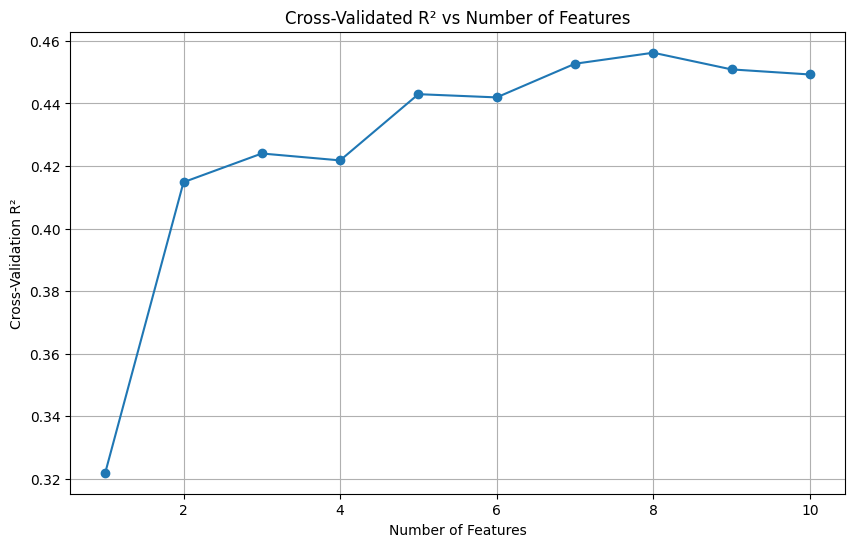

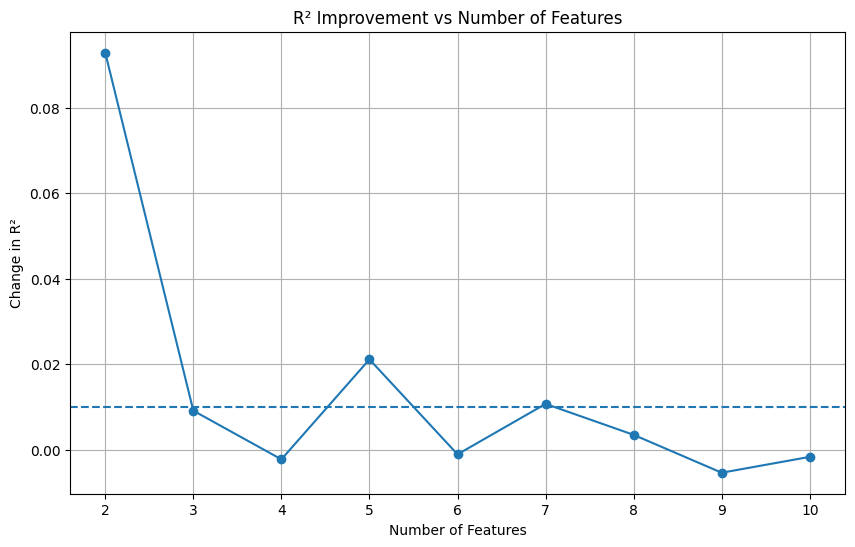

In [31]:
# Compare Full Model vs Reduced Model
print("\nComparison:")
print(f"Full Model -> Features: {X.shape[1]}, MSE: {full_mse:.2f}, R²: {full_r2:.2f}")
print(f"Reduced Model -> Features: {optimal_features}, MSE: {reduced_mse:.2f}, R²: {reduced_r2:.2f}")

# Visualize Cross-Validation Scores
import matplotlib.pyplot as plt

# --- Plot 1: R² vs Number of Features ---
plt.figure(figsize=(10, 6))
plt.plot(num_features, cv_scores, marker='o')
plt.title("Cross-Validated R² vs Number of Features")
plt.xlabel("Number of Features")
plt.ylabel("Cross-Validation R²")
plt.grid()
plt.show()


# --- Plot 2: R² Improvement ---
plt.figure(figsize=(10, 6))
plt.plot(num_features[1:], improvements, marker='o')
plt.axhline(threshold, linestyle='--')
plt.title("R² Improvement vs Number of Features")
plt.xlabel("Number of Features")
plt.ylabel("Change in R²")
plt.grid()
plt.show()

In [ ]:
# Task 4

In [36]:
full_coefs = pd.Series(full_model.coef_, index=X_train.columns)    # Ranking associated coefficents 
print(full_coefs.sort_values(key=abs, ascending=False))

s1    -931.488846
s5     736.198859
bmi    542.428759
s2     518.062277
bp     347.703844
s4     275.317902
sex   -241.964362
s3     163.419983
s6      48.670657
age     37.904021
dtype: float64


In [37]:
print("Final selected features:")
print(X_train.columns[rfe.support_])

Final selected features:
Index(['bmi', 's5'], dtype='object')
